# Louisville Crime Analysis 2004 - 2025

In [1]:
## import packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Create dotenv for Loading and Protecting Census API Key

In [2]:
!pip install python-dotenv

from dotenv import load_dotenv
import os
load_dotenv()
key = os.getenv("70c6096076838955c4273dc037180f6c3689ee79")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Combine Crime Reports, Create Dataframes for Each, and Add a 'Year' Column
- Goal of this prep work is to get a combined and cleaned dataframe that includes all years of crime with renaming of headers.

In [3]:
import glob

# Load all CSV files and sort in order
all_crime_files = sorted(glob.glob('../data/Crime_Data_*.csv'))

# Loop through each file, splits the file names to get year from file name, adds year column to each new df
crime_data_by_year = {}
for file in all_crime_files:
    year = int(file.split('_')[-1].replace('.csv', ''))
    crime_data_by_year[year] = pd.read_csv(file)
    crime_data_by_year[year]['year'] = year

# Rename individual dataframe to match all other code naming
df_2004 = crime_data_by_year[2004]
df_2005 = crime_data_by_year[2005]
df_2006 = crime_data_by_year[2006]
df_2007 = crime_data_by_year[2007]
df_2008 = crime_data_by_year[2008]
df_2009 = crime_data_by_year[2009]
df_2010 = crime_data_by_year[2010]
df_2011 = crime_data_by_year[2011]
df_2012 = crime_data_by_year[2012]
df_2013 = crime_data_by_year[2013]
df_2014 = crime_data_by_year[2014]
df_2015 = crime_data_by_year[2015]
df_2016 = crime_data_by_year[2016]
df_2017 = crime_data_by_year[2017]
df_2018 = crime_data_by_year[2018]
df_2019 = crime_data_by_year[2019]
df_2020 = crime_data_by_year[2020]
df_2021 = crime_data_by_year[2021]
df_2022 = crime_data_by_year[2022]
df_2023 = crime_data_by_year[2023]
df_2024 = crime_data_by_year[2024]
df_2025 = crime_data_by_year[2025]

/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/2625166126.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data_by_year[year] = pd.read_csv(file)
/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/2625166126.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data_by_year[year] = pd.read_csv(file)
/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/2625166126.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data_by_year[year] = pd.read_csv(file)
/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/2625166126.py:10: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  crime_data_by_year[year] = pd.read_csv(file)
/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/2625166126.

## Standardize Headers Across All Datasets

In [4]:
# Column mapping for 2004-2022 datasets (old names -> new names)
column_mapping = {
    'INCIDENT_NUMBER': 'incident_number',
    'DATE_REPORTED': 'date_reported',
    'DATE_OCCURED': 'date_occurred',
    'UOR_DESC': 'offense_code_name',
    'CRIME_TYPE': 'offense_classification',
    'NIBRS_CODE': 'nibrs_code',
    'UCR_HIERARCHY': 'nibrs_group_name',
    'ATT_COMP': 'was_offense_completed',
    'LMPD_DIVISION': 'lmpd_division',
    'LMPD_BEAT': 'lmpd_beat',
    'PREMISE_TYPE': 'location_category',
    'BLOCK_ADDRESS': 'block_address',
    'CITY': 'city',
    'City': 'city',
    'ZIP_CODE': 'zip_code',
    'BADGE_ID': 'badge_id'
}

# List of all dataframes to rename
dataframes = [df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010,
              df_2011, df_2012, df_2013, df_2014, df_2015, df_2016, df_2017,
              df_2018, df_2019, df_2020, df_2021, df_2022]

# Rename columns in each dataframe
for i, df in enumerate(dataframes):
    year = 2004 + i
    dataframes[i] = df.rename(columns=column_mapping)

# Reassign back to original variable names
df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010, \
df_2011, df_2012, df_2013, df_2014, df_2015, df_2016, df_2017, \
df_2018, df_2019, df_2020, df_2021, df_2022 = dataframes

## Merge All the Files Into One Dataframe

In [5]:
df_all_years = pd.concat([df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010,df_2011,df_2012,df_2013,df_2014,df_2015,df_2016,df_2017,df_2018, df_2019,df_2020,df_2021,df_2022,df_2023,df_2024,df_2025], ignore_index=True)
    
df_all_years.head()

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,ObjectId,year,badge_id
0,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,OPER MOTOR VEH U/INFLUENCE ALC/DRUGS/ETC .08-...,DUI,90D,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17556.0,1,2004,NaN
1,80-04-800064,5/22/04 10:20 PM,5/21/04 10:20 PM,POSS OF MARIJUANA,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,424,HIGHWAY / ROAD / ALLEY,700 BLOCK M ST ...,LOUISVILLE,40208.0,29447.0,2,2004,NaN
2,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,LEAVING SCENE OF ACCIDENT/FAILURE TO RENDER AI...,OTHER,0,NaN,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17766.0,3,2004,NaN
3,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,FAILURE OF OWNER TO MAINTAIN REQUIRED INS/SECU...,OTHER,90Z,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17767.0,4,2004,NaN
4,80-04-137493,12/18/04 4:40 PM,12/18/04 4:00 AM,CRIMINAL MISCHIEF-3RD DEGREE,VANDALISM,290,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,5200 BLOCK RUSSETT BLVD ...,LOUISVILLE,40218.0,17904.0,5,2004,NaN


## Remove the 'ObjectID' Column

### The ID column does not have a purpose and should be removed

In [6]:
if 'ObjectId' in df_all_years.columns:
    df_all_years = df_all_years.drop(columns=['ObjectId'])
    print("ObjectId column dropped from df_all_years")
else:
    print("ObjectId column not found in df_all_years")

ObjectId column dropped from df_all_years


In [7]:
# Check headers and columns
df_all_years.head()

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,year,badge_id
0,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,OPER MOTOR VEH U/INFLUENCE ALC/DRUGS/ETC .08-...,DUI,90D,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17556.0,2004,NaN
1,80-04-800064,5/22/04 10:20 PM,5/21/04 10:20 PM,POSS OF MARIJUANA,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,424,HIGHWAY / ROAD / ALLEY,700 BLOCK M ST ...,LOUISVILLE,40208.0,29447.0,2004,NaN
2,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,LEAVING SCENE OF ACCIDENT/FAILURE TO RENDER AI...,OTHER,0,NaN,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17766.0,2004,NaN
3,80-04-203312,1/29/04 10:20 AM,1/29/04 10:20 AM,FAILURE OF OWNER TO MAINTAIN REQUIRED INS/SECU...,OTHER,90Z,PART II,COMPLETED,2ND DIVISION,225,HIGHWAY / ROAD / ALLEY,S 23RD ST / W BURNETT AVE ...,LOUISVILLE,40210.0,17767.0,2004,NaN
4,80-04-137493,12/18/04 4:40 PM,12/18/04 4:00 AM,CRIMINAL MISCHIEF-3RD DEGREE,VANDALISM,290,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,5200 BLOCK RUSSETT BLVD ...,LOUISVILLE,40218.0,17904.0,2004,NaN


## Check for Duplicates and Null Values


In [8]:
# Check Null values. Null counts with years as rows, columns as headers
null_by_year = df_all_years.groupby('year').apply(lambda x: x.isnull().sum())

# Display full table without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(null_by_year)


      incident_number  date_reported  date_occurred  offense_code_name  \
year                                                                     
2004                0              0              0                  0   
2005                0              0              0                  0   
2006                0              0              3                  0   
2007                0              0              1                  0   
2008                0              0             33                  0   
2009                0              0            131                  0   
2010                0              0             73                  0   
2011                0              0             58                  0   
2012                0              0             20                  0   
2013                0              0              6                  0   
2014                0              0              4                  0   
2015                0              0  

/var/folders/rt/rt9sdyhn03b7bz7l20vpzlm40000gn/T/ipykernel_56037/4001133387.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_by_year = df_all_years.groupby('year').apply(lambda x: x.isnull().sum())


In [9]:
# Display summary
print(df_all_years['year'].value_counts().sort_index())

year
2004    70696
2005    77347
2006    83851
2007    90767
2008    86481
2009    78380
2010    82871
2011    86013
2012    81406
2013    77127
2014    77466
2015    79839
2016    84535
2017    82113
2018    80000
2019    73420
2020    70233
2021    72127
2022    71506
2023    71421
2024    70768
2025    67253
Name: count, dtype: int64


In [10]:
df_all_years.isna().sum()

incident_number                 0
date_reported                  19
date_occurred                 345
offense_code_name               2
offense_classification        362
nibrs_code                      0
nibrs_group_name            56997
was_offense_completed        2840
lmpd_division                 670
lmpd_beat                    7213
location_category           10147
block_address                5945
city                         4433
zip_code                     5430
ID                         496728
year                            0
badge_id                  1362594
dtype: int64

In [11]:
# Finding duplicates 
df_all_years.loc[df_all_years.duplicated()].head(10)

,incident_number,date_reported,date_occurred,offense_code_name,offense_classification,nibrs_code,nibrs_group_name,was_offense_completed,lmpd_division,lmpd_beat,location_category,block_address,city,zip_code,ID,year,badge_id
1221041,80-19-002756,2019/01/11 11:38:00,2019/01/11 11:38:00,ATT/OBTAIN CONTSUB BY FRAUD/FLS STMT/FORGERY,FRAUD,26A,PART II,COMPLETED,1ST DIVISION,135,DRUG STORE/DR`S OFFICE/HOSPITAL,500 BLOCK S JACKSON ST ...,LOUISVILLE,40202,NaN,2019,NaN
1221042,80-19-002756,2019/01/11 11:38:00,2019/01/11 11:38:00,ATT/OBTAIN CONTSUB BY FRAUD/FLS STMT/FORGERY,FRAUD,26A,PART II,COMPLETED,1ST DIVISION,135,DRUG STORE/DR`S OFFICE/HOSPITAL,500 BLOCK S JACKSON ST ...,LOUISVILLE,40202,NaN,2019,NaN
1222125,80-19-004169,2019/01/16 20:45:00,2019/01/16 10:00:00,"TBUT OR DISP ALL OTHERS $1,000,000 OR MORE",THEFT/LARCENY,23H,PART I,COMPLETED,8TH DIVISION,824,RESIDENCE / HOME,10700 BLOCK SHELBYVILLE RD ...,DOUGLASS_HILLS,40243,NaN,2019,NaN
1223011,80-19-005157,2019/01/20 18:52:00,2019/01/20 17:53:00,BURGLARY - 2ND DEGREE,BURGLARY,220,PART I,COMPLETED,4TH DIVISION,411,RESIDENCE / HOME,1100 BLOCK S BROOK ST ...,LOUISVILLE,40203,NaN,2019,NaN
1224607,80-19-007288,2019/01/29 11:13:00,2019/01/29 10:55:00,ASSAULT - 3RD DEGREE (SCHOOL EMPLOYEE OR SCHOO...,ASSAULT,13B,PART II,COMPLETED,3RD DIVISION,315,SCHOOL - ELEMENTARY / SECONDARY,10200 BLOCK DIXIE HWY ...,LOUISVILLE,40272,NaN,2019,NaN
1229226,80-19-012866,2019/02/19 23:30:00,2019/02/19 22:40:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,436,OTHER RESIDENCE (APARTMENT/CONDO),4600 BLOCK SOUTHERN PKY ...,LOUISVILLE,40214,NaN,2019,NaN
1230801,80-19-014616,2019/02/27 04:50:00,2019/02/27 04:50:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,1ST DIVISION,111,RESIDENCE / HOME,2000 BLOCK W MAIN ST ...,LOUISVILLE,40203,NaN,2019,NaN
1231194,80-19-015052,2019/02/28 18:18:00,2019/02/28 17:30:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,6TH DIVISION,613,RESIDENCE / HOME,3300 BLOCK INDIAN CREEK CT ...,LOUISVILLE,40218,NaN,2019,NaN
1231385,80-19-015508,2019/03/02 16:43:00,2019/03/02 16:43:00,POSS CONT SUB-2ND DEGREE-DRUG UNSPECIFIED,DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,412,HIGHWAY / ROAD / ALLEY,2200 BLOCK S 3RD ST ...,LOUISVILLE,40208,NaN,2019,NaN
1235266,80-19-020173,2019/03/21 13:55:00,2019/03/21 13:50:00,TRAFF IN CONTROLLED SUBST 2ND OR > OFF (HEROIN),DRUGS/ALCOHOL VIOLATIONS,35A,PART II,COMPLETED,4TH DIVISION,435,HIGHWAY / ROAD / ALLEY,4500 BLOCK HAZELWOOD AVE ...,LOUISVILLE,40214,NaN,2019,NaN


### incident_number are duplicated tracking multiple offenses for one stop. For this analysis the information does not effect the insights so will be noted.

- One consideration is the long-tail of 6+ offenses per incident. Due to less than 0.1% of the data effected, it will be ignored.

In [12]:
# Offenses per incident_number distribution
offenses_per_incident = df_all_years.groupby('incident_number').size()

offense_counts = offenses_per_incident.value_counts().sort_index()

offense_table = pd.DataFrame({
    'offenses_per_incident': offense_counts.index,
    'num_incidents': offense_counts.values,
    'pct_of_incidents': (offense_counts.values / offense_counts.sum() * 100).round(1)
}).reset_index(drop=True)

print(f"Total rows:              {len(df_all_years):,}")
print(f"Unique incident numbers: {offenses_per_incident.nunique():,}")
print(f"Average offenses/incident: {offenses_per_incident.mean():.2f}\n")

offense_table

Total rows:              1,715,620
Unique incident numbers: 19
Average offenses/incident: 1.22



,offenses_per_incident,num_incidents,pct_of_incidents
0,1,1192456,84.7
1,2,154439,11.0
2,3,39010,2.8
3,4,14948,1.1
4,5,3904,0.3
5,6,1582,0.1
6,7,666,0.0
7,8,274,0.0
8,9,90,0.0
9,10,42,0.0


### Overall Louisville Crime Trend

In [13]:
crimes_by_year = df_all_years.groupby('year').size()
print(crimes_by_year)

year
2004    70696
2005    77347
2006    83851
2007    90767
2008    86481
2009    78380
2010    82871
2011    86013
2012    81406
2013    77127
2014    77466
2015    79839
2016    84535
2017    82113
2018    80000
2019    73420
2020    70233
2021    72127
2022    71506
2023    71421
2024    70768
2025    67253
dtype: int64


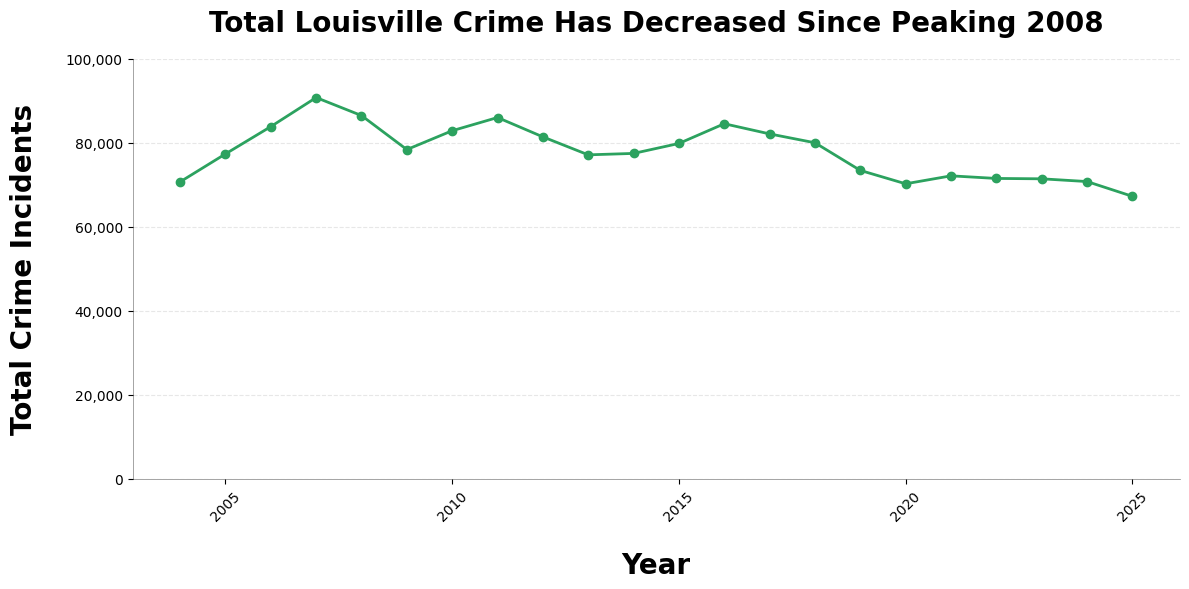

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(crimes_by_year.index,
         crimes_by_year.values,
         marker = "o",
         linestyle = "-",
         color = "#2ca25f",
         linewidth = 2)

plt.xlabel("Year", fontsize=20, labelpad=20, fontweight='bold')
plt.ylabel("Total Crime Incidents", labelpad=20,fontsize=20, fontweight='bold')
plt.title("Total Louisville Crime Has Decreased Since Peaking 2008", fontweight='bold',fontsize=20, pad=20)
plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0,100_000)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Formatting the y axis number with a comma
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Build API access. 
- Use postman as software
- Use to check API information
- Set up account (postman) https://www.postman.com/
- Census API Key: 70c6096076838955c4273dc037180f6c3689ee79 >> get updated version
- USe Economic indicators API for poverty level?
- build a loop to take a zip code, then give it specific code, filter an array, build the dataframe, append to a list, etc. have dataframe, export.
- Check for an easier api for metrics you are seeking.
-- https://aspe.hhs.gov/topics/poverty-economic-mobility/poverty-guidelines/poverty-guidelines-api


## Offense Analysis
- offense_classificataion renaming for continuous 2004 to 2025 analysis.

Data reveals that offense_classifications changed in 2023, expanding from 16 categories to 57. I will need to recategorize and rename classifications so that I can better measure the change over time.

Additionally, the classification names do not match 1:1. The new names in 2023 include a numeric value which will need to be removed when renamed.

In [15]:
# Set pandas display options to show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Create the summary table
summary_df = df_all_years.groupby(['year', 'offense_classification']).size().unstack(fill_value=0)

# Display it
summary_df

offense_classification,1 HOMICIDE,1 NONE,10 KIDNAPPING ONLY,11 SIMPLE ASSAULT,12 INTIMIDATION,13 BURGLARY,14 AUTO THEFT,15 UNAUTHORIZED USE,16 PURSE SNATCH,17 PICK POCKET,18 SHOPLIFTING,19 THEFT FR BLDG,2 NEGLIGENT HOMICIDE,20 THEFT FR VEND MACHINE,21 THEFT FR VEH,22 THEFT MV PARTS,23 LARCENY,23 THEFT OTHER,24 VANDALISM,25 EXTORTION,26 COUNTERFEITING,27 FRAUD,28 FRAUD CREDIT CARD/ATM,29 FRAUD IMPERSONATION,3 JUSTIFIABLE HOMICIDE,32 EMBEZZLEMENT,32 THEFT FR BLDG,33 STOLEN PROPERTY,34 NARCOTICS,35 NARCOTICS EQUIP,36 INCEST,37 STAT RAPE,38 PORNOGRAPHY,4 FORCIBLE RAPE,43 PROSTITUTION,44 PROMOTING PROSTITUTION,45 BRIBERY,46 FAMILY OFFENSES,46 WPNS LAW VIOLATION,47 FAMILY OFFENSES,49 LOITERING/CURFEW VIOL,5 SODOMY FORCE,50 DRUNK DRIVING,51 DISORDERLY CONDUCT,52 DRUNKENNESS,53 LIQUOR LAW VIOLATION,54 VOYEURISM,55 TRESPASSING,56 ALL OTHER CRIMES,56 ALL OTHER OFFENSES,56 NON REPORTABLE,58 ARSON,7 FORCIBLE FONDLING,8 ROBBERY,9 AGGRAVATED ASSAULT,99 NON-REPORTABLE,99 OTHER CRIMES,ARSON,ASSAULT,BURGLARY,DISTURBING THE PEACE,DRUGS/ALCOHOL VIOLATIONS,DUI,FRAUD,HOMICIDE,MOTOR VEHICLE THEFT,OTHER,ROBBERY,SEX CRIMES,THEFT/LARCENY,VANDALISM,VEHICLE BREAK-IN/THEFT,WEAPONS
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,22,6565,7155,1492,10632,294,2418,72,3345,10459,1471,725,11149,8119,6221,557
2005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,19,7214,7318,2148,11523,292,3656,64,3364,11667,1859,716,11303,8498,7042,664
2006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,7365,7869,2422,13724,314,3737,56,4085,13734,1849,785,12194,7758,7197,744
2007,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,8416,7893,2656,15723,338,3818,77,3616,16874,1982,803,13394,7670,6733,762
2008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,9168,7305,1795,12603,221,3534,75,3040,17316,1833,769,13851,7460,6770,728
2009,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,9220,7141,739,12615,30,3484,68,2106,14203,1624,814,12993,6688,5917,728
2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,10345,7610,553,13452,14,3070,60,2318,14983,1626,643,13815,6638,7012,729
2011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,10490,8080,492,13419,21,3077,50,2623,15844,1661,711,15837,6422,6529,747
2012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,12936,7147,581,16065,7,3070,65,2448,9808,1427,745,15147,5868,5270,818


In [16]:
# Get offense classifications from 2004-2022
offenses_2004_2022 = df_all_years[df_all_years['year'] <= 2022]['offense_classification'].dropna().unique()
offenses_2004_2022_sorted = sorted(offenses_2004_2022)


print("OFFENSE CLASSIFICATIONS FROM 2004-2022")
print(f"Total unique: {len(offenses_2004_2022_sorted)}\n")
for offense in offenses_2004_2022_sorted:
    print(offense)

print("OFFENSE CLASSIFICATIONS FROM 2023-2025")

# Get offense classifications from 2023-2025
offenses_2023_2025 = df_all_years[df_all_years['year'] >= 2023]['offense_classification'].dropna().unique()
offenses_2023_2025_sorted = sorted(offenses_2023_2025)

print(f"Total unique: {len(offenses_2023_2025_sorted)}\n")
for offense in offenses_2023_2025_sorted:
    print(offense)

OFFENSE CLASSIFICATIONS FROM 2004-2022
Total unique: 16

ARSON
ASSAULT
BURGLARY
DISTURBING THE PEACE
DRUGS/ALCOHOL VIOLATIONS
DUI
FRAUD
HOMICIDE
MOTOR VEHICLE THEFT
OTHER
ROBBERY
SEX CRIMES
THEFT/LARCENY
VANDALISM
VEHICLE BREAK-IN/THEFT
WEAPONS
OFFENSE CLASSIFICATIONS FROM 2023-2025
Total unique: 57

1 HOMICIDE
1 NONE
10 KIDNAPPING ONLY
11 SIMPLE ASSAULT
12 INTIMIDATION
13 BURGLARY
14 AUTO THEFT
15 UNAUTHORIZED USE
16 PURSE SNATCH
17 PICK POCKET
18 SHOPLIFTING
19 THEFT FR BLDG
2 NEGLIGENT HOMICIDE
20 THEFT FR VEND MACHINE
21 THEFT FR VEH
22 THEFT MV PARTS
23 LARCENY
23 THEFT OTHER
24 VANDALISM
25 EXTORTION
26 COUNTERFEITING
27 FRAUD
28 FRAUD CREDIT CARD/ATM
29 FRAUD IMPERSONATION
3 JUSTIFIABLE HOMICIDE
32 EMBEZZLEMENT
32 THEFT FR BLDG
33 STOLEN PROPERTY
34 NARCOTICS
35 NARCOTICS EQUIP
36 INCEST
37 STAT RAPE
38 PORNOGRAPHY
4 FORCIBLE RAPE
43 PROSTITUTION
44 PROMOTING PROSTITUTION
45 BRIBERY
46 FAMILY OFFENSES
46 WPNS LAW VIOLATION
47 FAMILY OFFENSES
49 LOITERING/CURFEW VIOL
5 SODOMY FOR

In [17]:
# Create a copy of df_all_years
df_all_years_cleaned = df_all_years.copy()

# Create mapping dictionary for 2023-2025 classifications to match 2004-2022
offense_mapping = {
    # ARSON
    '58 ARSON': 'ARSON',
    
    # ASSAULT
    '10 KIDNAPPING ONLY': 'ASSAULT',
    '11 SIMPLE ASSAULT': 'ASSAULT',
    '9 AGGRAVATED ASSAULT': 'ASSAULT',
    '12 INTIMIDATION': 'ASSAULT',
    
    # BURGLARY
    '13 BURGLARY': 'BURGLARY',
    
    # DISTURBING THE PEACE
    '51 DISORDERLY CONDUCT': 'DISTURBING THE PEACE',
    
    # DRUGS/ALCOHOL VIOLATIONS
    '34 NARCOTICS': 'DRUGS/ALCOHOL VIOLATIONS',
    '35 NARCOTICS EQUIP': 'DRUGS/ALCOHOL VIOLATIONS',
    '52 DRUNKENNESS': 'DRUGS/ALCOHOL VIOLATIONS',
    '53 LIQUOR LAW VIOLATION': 'DRUGS/ALCOHOL VIOLATIONS',
    
    # DUI
    '50 DRUNK DRIVING': 'DUI',
    
    # FRAUD
    '26 COUNTERFEITING': 'FRAUD',
    '27 FRAUD': 'FRAUD',
    '28 FRAUD CREDIT CARD/ATM': 'FRAUD',
    '29 FRAUD IMPERSONATION': 'FRAUD',
    '32 EMBEZZLEMENT': 'FRAUD',
    '45 BRIBERY': 'FRAUD',
    '25 EXTORTION': 'FRAUD',
    
    # HOMICIDE
    '1 HOMICIDE': 'HOMICIDE',
    '2 NEGLIGENT HOMICIDE': 'HOMICIDE',
    '3 JUSTIFIABLE HOMICIDE': 'HOMICIDE',
    
    # MOTOR VEHICLE THEFT
    '14 AUTO THEFT': 'MOTOR VEHICLE THEFT',
    
    # OTHER
    '1 NONE': 'OTHER',
    '15 UNAUTHORIZED USE': 'OTHER',
    '99 OTHER CRIMES': 'OTHER',
    '46 FAMILY OFFENSES': 'OTHER',
    '47 FAMILY OFFENSES': 'OTHER',
    '49 LOITERING/CURFEW VIOL': 'OTHER',
    '55 TRESPASSING': 'OTHER',
    '56 ALL OTHER CRIMES': 'OTHER',
    '56 ALL OTHER OFFENSES': 'OTHER',
    '56 NON REPORTABLE': 'OTHER',
    '99 NON-REPORTABLE': 'OTHER',
    
    # ROBBERY
    '8 ROBBERY': 'ROBBERY',
    
    # SEX CRIMES
    '36 INCEST': 'SEX CRIMES',
    '37 STAT RAPE': 'SEX CRIMES',
    '38 PORNOGRAPHY': 'SEX CRIMES',
    '4 FORCIBLE RAPE': 'SEX CRIMES',
    '5 SODOMY FORCE': 'SEX CRIMES',
    '43 PROSTITUTION': 'SEX CRIMES',
    '44 PROMOTING PROSTITUTION': 'SEX CRIMES',
    '54 VOYEURISM': 'SEX CRIMES',
    '7 FORCIBLE FONDLING': 'SEX CRIMES',
    
    # THEFT/LARCENY
    '17 PICK POCKET': 'THEFT/LARCENY',
    '18 SHOPLIFTING': 'THEFT/LARCENY',
    '19 THEFT FR BLDG': 'THEFT/LARCENY',
    '20 THEFT FR VEND MACHINE': 'THEFT/LARCENY',
    '23 LARCENY': 'THEFT/LARCENY',
    '23 THEFT OTHER': 'THEFT/LARCENY',
    '32 THEFT FR BLDG': 'THEFT/LARCENY',
    '33 STOLEN PROPERTY': 'THEFT/LARCENY',
    '16 PURSE SNATCH': 'THEFT/LARCENY',
    
    # VANDALISM
    '24 VANDALISM': 'VANDALISM',
    
    # VEHICLE BREAK-IN/THEFT
    '22 THEFT MV PARTS': 'VEHICLE BREAK-IN/THEFT',
    '21 THEFT FR VEH': 'VEHICLE BREAK-IN/THEFT',
    
    # WEAPONS
    '46 WPNS LAW VIOLATION': 'WEAPONS',
}

# Apply the mapping to the new dataframe
df_all_years_cleaned['offense_classification'] = df_all_years_cleaned['offense_classification'].replace(offense_mapping)


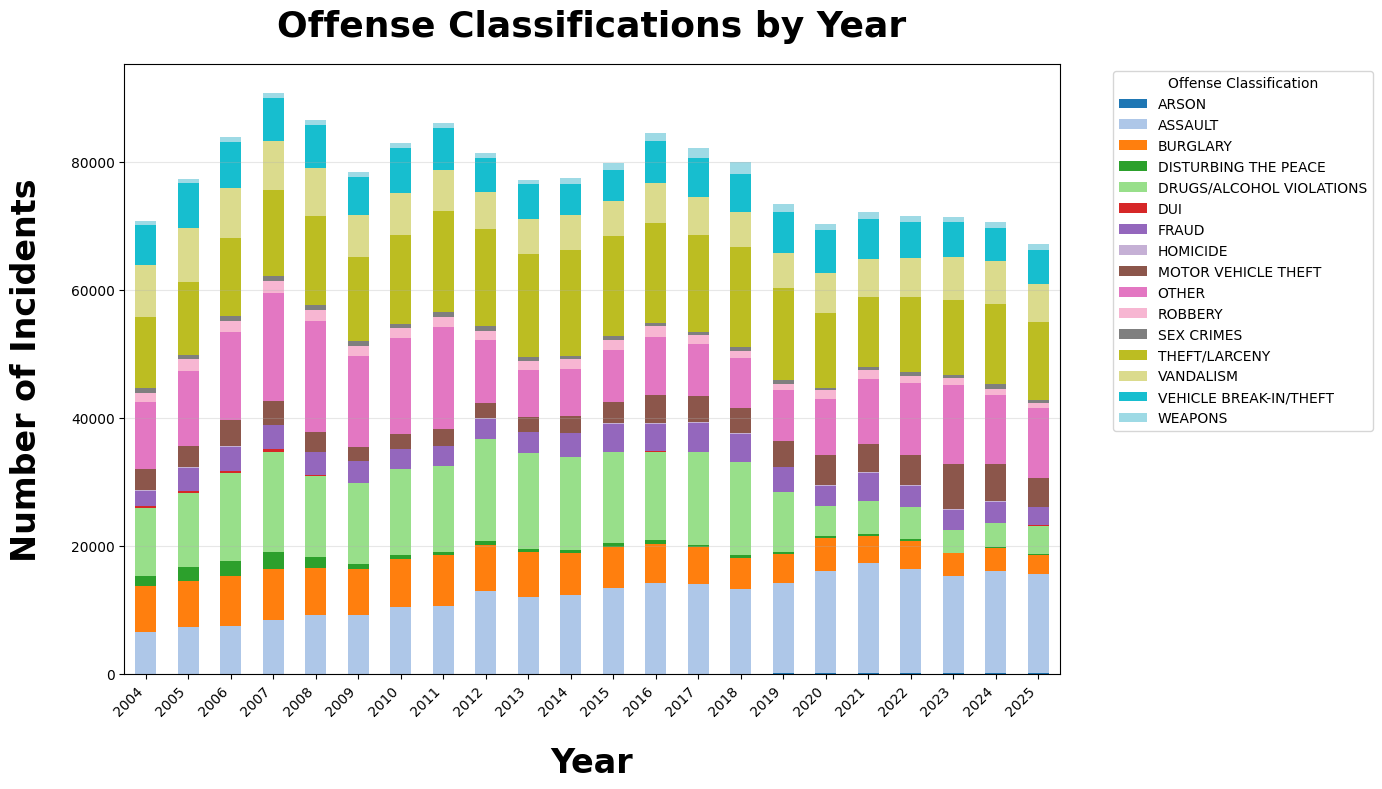

In [18]:
# Create pivot table with offense classifications by year
crime_by_year = df_all_years_cleaned.groupby(['year', 'offense_classification']).size().unstack(fill_value=0)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
crime_by_year.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Year', labelpad=20,fontsize=24, fontweight='bold')
ax.set_ylabel('Number of Incidents', labelpad=20,fontsize=24, fontweight='bold')
ax.set_title('Offense Classifications by Year',fontsize=26, fontweight='bold', pad=20)
ax.legend(title='Offense Classification', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


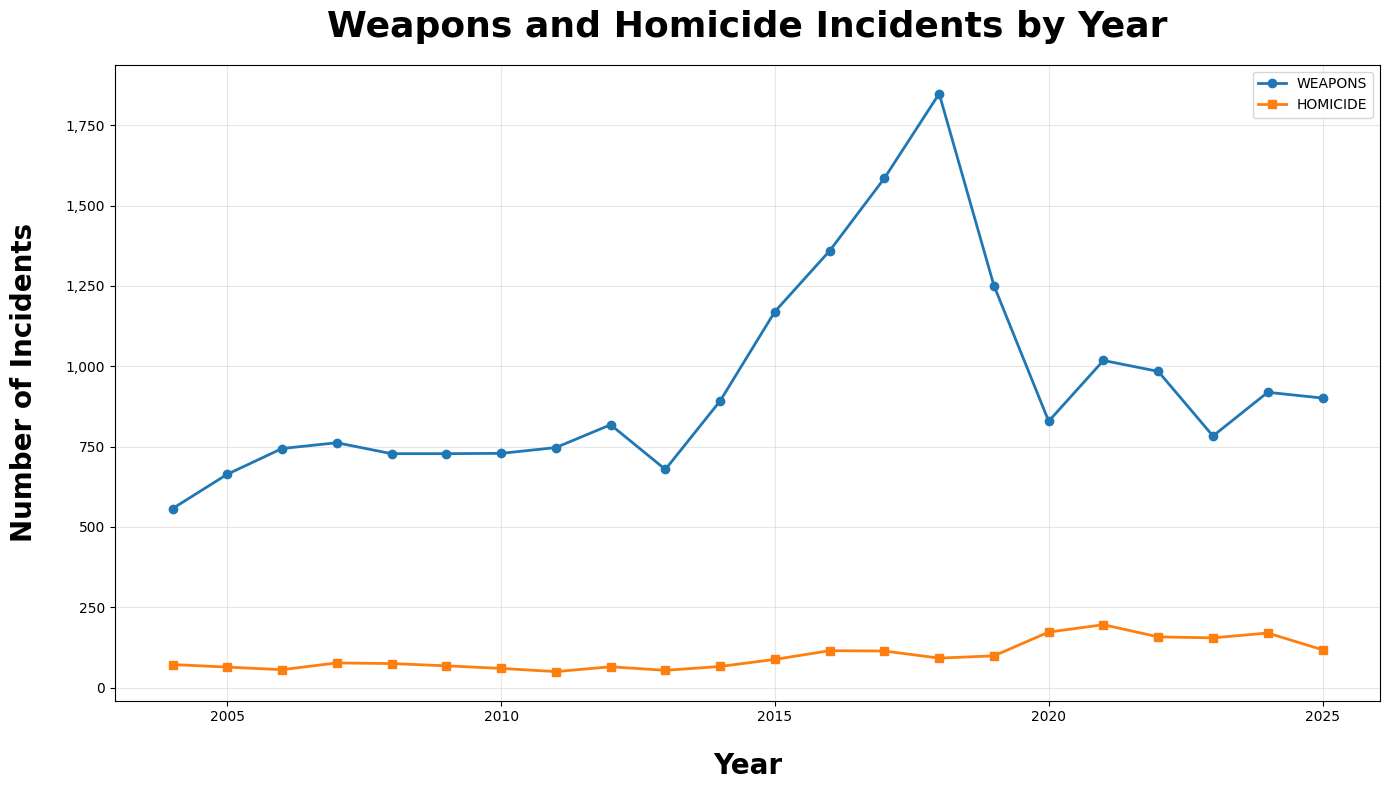

In [19]:
# Create summary by year for WEAPONS and HOMICIDE
weapons_homicide = df_all_years_cleaned[df_all_years_cleaned['offense_classification'].isin(['WEAPONS', 'HOMICIDE'])]

# Group by year and offense classification
summary = weapons_homicide.groupby(['year', 'offense_classification']).size().unstack(fill_value=0)

# Create line chart
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(summary.index, summary['WEAPONS'], marker='o', linewidth=2, label='WEAPONS')
ax.plot(summary.index, summary['HOMICIDE'], marker='s', linewidth=2, label='HOMICIDE')

ax.set_xlabel('Year', labelpad=20,fontsize=20, fontweight='bold')
ax.set_ylabel('Number of Incidents', labelpad=20,fontsize=20, fontweight='bold')
ax.set_title('Weapons and Homicide Incidents by Year', pad=20,fontsize=26, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## Overall Analysis of Crime Trends

# Beginning of API Calls to Join Data

In [21]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
key = os.getenv("CENSUS_API_KEY")
print("Key loaded:", "YES" if key else "NO")

# Louisville-area ZIP codes (ZCTAs)
louisville_zips = [
    "40202", "40203", "40204", "40205", "40206", "40207", "40208", "40209",
    "40210", "40211", "40212", "40213", "40214", "40215", "40216", "40217",
    "40218", "40219", "40220", "40221", "40222", "40223", "40224", "40225",
    "40228", "40229", "40231", "40232", "40233", "40241", "40242", "40243",
    "40245", "40258", "40272", "40291", "40299"
]

# ACS variables to pull — Census variable codes mapped to human-readable names.
# To browse all available variables: https://api.census.gov/data/2022/acs/acs5/variables.html
VARIABLES = {
    # Core demographics
    "B01003_001E": "total_population",
    "B01002_001E": "median_age",

    # Income & poverty
    "B19013_001E": "median_household_income",
    "B17001_002E": "population_below_poverty",

    # Housing
    "B25077_001E": "median_home_value",        # Not available in 2011 — handled below
    "B25070_010E": "rent_burden_50pct_plus",   # Households paying 50%+ income on rent

    # Education
    "B15003_002E": "no_schooling",
    "B15003_021E": "associates_degree",
    "B15003_022E": "bachelors_degree",
    "B15003_023E": "masters_degree",
    "B15003_025E": "professional_degree",

    # Employment
    "B23025_005E": "unemployed_population",    # Civilian unemployed, in labor force

    # Household structure
    "B11001_006E": "single_parent_households", # Female householder, no spouse present

    # Residential mobility — population that moved in the past year
    "B07003_004E": "moved_past_year",
}

# Variables not available in 2011 — will be excluded for that year only.
# Affected rows will have NaN for these columns in 2011.
UNAVAILABLE_2011 = {"B25077_001E", "B25070_010E", "B07003_004E"}

# 2009-2010 don't support ZIP geography in ACS 5-year.
# 2011 is available but missing some variables (see UNAVAILABLE_2011).
years = list(range(2011, 2024))


def pull_acs_year(year):
    """Pull ACS 5-year data for all ZCTAs via raw API call, filter to Louisville."""

    # Drop variables known to be unavailable in 2011 to avoid 400 errors
    if year == 2011:
        variables = {k: v for k, v in VARIABLES.items() if k not in UNAVAILABLE_2011}
    else:
        variables = VARIABLES

    var_list = "NAME," + ",".join(variables.keys())
    url = (
        f"https://api.census.gov/data/{year}/acs/acs5"
        f"?get={var_list}"
        f"&for=zip%20code%20tabulation%20area:*"
        f"&key={key}"
    )

    try:
        r = requests.get(url)
        r.raise_for_status()
        data = r.json()

        # First row from Census API is always the header row
        headers = data[0]
        rows = data[1:]
        df = pd.DataFrame(rows, columns=headers)

        # Filter down to Louisville ZCTAs only
        df = df[df["zip code tabulation area"].isin(louisville_zips)].copy()
        df = df.rename(columns={"zip code tabulation area": "zip_code"})
        df = df.rename(columns=variables)
        df["year"] = year

        # Convert all variable columns to numeric.
        # errors="coerce" turns any non-numeric values into NaN.
        numeric_cols = list(variables.values())
        df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

        # Census uses -666666666 as a sentinel for suppressed/unavailable data.
        # Replace with NaN so it doesn't distort calculations.
        df[numeric_cols] = df[numeric_cols].replace(-666666666, pd.NA)

        # --- Derived fields ---

        # Poverty rate as a percentage of total population
        df["poverty_rate"] = (
            df["population_below_poverty"] / df["total_population"] * 100
        ).round(2)

        # % of population with bachelor's degree or higher
        df["pct_bachelors_plus"] = (
            (df["bachelors_degree"] + df["masters_degree"] +
             df["professional_degree"]) / df["total_population"] * 100
        ).round(2)

        # Unemployment rate as a percentage of total population
        df["unemployment_rate"] = (
            df["unemployed_population"] / df["total_population"] * 100
        ).round(2)

        # Residential mobility rate — % of population that moved in past year
        df["mobility_rate"] = (
            df["moved_past_year"] / df["total_population"] * 100
        ).round(2) if "moved_past_year" in df.columns else pd.NA

        print(f"  {year}: {len(df)} ZIPs pulled")
        return df

    except Exception as e:
        print(f"  {year}: FAILED — {e}")
        return None


def build_demographics_table():
    """Loop through all years, pull ACS data, and combine into one DataFrame."""
    frames = []
    for year in years:
        print(f"Pulling {year}...")
        df = pull_acs_year(year)
        if df is not None:
            frames.append(df)

    if not frames:
        raise ValueError("No data was pulled — check your API key and connection.")

    combined = pd.concat(frames, ignore_index=True)

    # Warn about any columns with more than 20% missing values across all rows.
    # Per project plan, avoid drawing insights from these fields.
    missing_pct = combined.isnull().mean()
    high_missing = missing_pct[missing_pct > 0.2].index.tolist()
    if high_missing:
        print(f"\nWarning: High missing data in columns: {high_missing}")

    return combined


if __name__ == "__main__":
    print("Pulling ACS 5-year data for Louisville ZIPs...\n")
    df = build_demographics_table()

    output_path = "data/louisville_demographics.csv"
    os.makedirs("data", exist_ok=True)
    df.to_csv(output_path, index=False)

    print(f"\nDone. {len(df)} rows saved to {output_path}")
    print(df[["zip_code", "year", "median_household_income",
              "poverty_rate", "unemployment_rate",
              "mobility_rate", "single_parent_households"]].head(10))

Key loaded: YES
Pulling ACS 5-year data for Louisville ZIPs...

Pulling 2011...
  2011: FAILED — 400 Client Error:  for url: https://api.census.gov/data/2011/acs/acs5?get=NAME,B01003_001E,B01002_001E,B19013_001E,B17001_002E,B15003_002E,B15003_021E,B15003_022E,B15003_023E,B15003_025E,B23025_005E,B11001_006E&for=zip%20code%20tabulation%20area:*&key=e9d4b6f4dd0dbeab73515ae32f4cb33ed4ab5dba
Pulling 2012...
  2012: 32 ZIPs pulled
Pulling 2013...
  2013: 32 ZIPs pulled
Pulling 2014...
  2014: 32 ZIPs pulled
Pulling 2015...
  2015: 32 ZIPs pulled
Pulling 2016...
  2016: 32 ZIPs pulled
Pulling 2017...
  2017: 32 ZIPs pulled
Pulling 2018...
  2018: 32 ZIPs pulled
Pulling 2019...
  2019: 32 ZIPs pulled
Pulling 2020...
  2020: 32 ZIPs pulled
Pulling 2021...
  2021: 33 ZIPs pulled
Pulling 2022...
  2022: 33 ZIPs pulled
Pulling 2023...
  2023: 33 ZIPs pulled


Done. 387 rows saved to data/louisville_demographics.csv
  zip_code  year median_household_income  poverty_rate  unemployment_rate  \
0    4